In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Predicting Airbnb Listing Prices in Melbourne, Australia

In [ ]:
# Import neccessary library
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from math import radians, cos, sin, asin, sqrt

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel

print('Done')

In [5]:
path_test = '/content/drive/MyDrive/Model Citizens/test.csv'
path_train = '/content/drive/MyDrive/Model Citizens/train.csv'

test_df = pd.read_csv(path_test)
train_df = pd.read_csv(path_train)

---
---

## I: Problem Description and Initial Data Analysis



### 1. Forecasting Problem and Dataset Overview

The aim of this competition is to predict Airbnb listing prices in Melbourne using property and host-related features. This is a supervised regression task with `price` as the target variable. Accurate price predictions can benefit:

- **Hosts** – by setting competitive, data-driven prices
- **Airbnb** – by offering better pricing tools and market insights
- **Guests** – by enabling fairer pricing and better planning (matching their budget and preference)
- **Investors** – through informed market analysis

The dataset includes:

- **train.csv** – 7,000 rows × 61 columns (includes `price`)
- **test.csv** – 3,000 rows × 60 columns (without `price`)

Each row represents a unique listing with mixed data types (numeric, categorical, and text).

### 2. Evaluation Criteria – Mean Absolute Error (MAE)

This competition uses Mean Absolute Error (MAE) to evaluate model performance. MAE calculates the average of absolute differences between predicted and actual prices.

**Pros:**
- Easy to interpret.
- Penalizes large and small errors equally.
- Robust to outliers compared to RMSE.

**Cons:**
- Doesn’t distinguish between under-prediction and over-prediction.
- May not penalize large deviations as strongly as RMSE.


### 3. Variable Classification

I reviewed all variables and classified them into three types: **Numeric**, **Ordinal**, and **Nominal**, based on data type and structure. The target variable `price` was excluded, as it's used only for prediction.


| Variable Kind | Number of Features | Feature Names |
|---------------|---------------------|---------------|
| **Numeric**   | 17                  | calculated_host_listings_count, calculated_host_listings_count_entire_homes, calculated_host_listings_count_private_rooms, calculated_host_listings_count_shared_rooms,<br>host_listings_count, host_acceptance_rate, host_response_rate, ID, latitude, longitude, accommodates, bedrooms, beds, minimum_nights, maximum_nights,  maximum_minimum_nights, minimum_minimum_nights,<br>maximum_maximum_nights, minimum_maximum_nights, minimum_nights_avg_ntm, maximum_nights_avg_ntm, availability_30, availability_60, availability_90, availability_365, <br>number_of_reviews, number_of_reviews_ltm, number_of_reviews_l30d, price |
| **Ordinal**   | 8                   | host_response_time, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value |
| **Nominal**   | 34                  | source, name, description, neighborhood_overview, host_name, host_since, host_location, host_about, host_is_superhost, host_neighbourhood, host_verifications, host_has_profile_pic, host_identity_verified,<br>neighbourhood, neighbourhood_cleansed, property_type, room_type, amenities, has_availability, instant_bookable,  first_review, last_review, bathrooms |

Definitions:


- **Numeric (17)**: Continuous values used directly in modeling.
- **Ordinal (8)**: Ordered categories, like `host_response_time` and review scores.
- **Nominal (34)**: Categorical variables without order, e.g., `room_type`, `host_name`, `property_type`.


Correct classification is essential to determine appropriate preprocessing steps like encoding or scaling, which will be implemented in Task 2.

### 4. Missing Values

The goal is to assess and report the quality of both the **training** and **test datasets** by identifying missing values. This step helps inform future feature engineering and model development.


| Feature                         | Train Missing | Test Missing |
|---------------------------------|----------------|---------------|
| host_neighbourhood              | 3,460          | 2,066         |
| host_about                      | 2,270          | 1,441         |
| neighborhood_overview           | 1,823          | 1,424         |
| neighbourhood                   | 1,823          | 1,424         |
| host_location                   | 1,280          | 770           |
| bedrooms                        | 378            | 60            |
| room_type                       | 134            | 41            |
| host_response_time              | —              | 737           |
| host_response_rate              | —              | 737           |
| host_acceptance_rate            | —              | 658           |
| review_scores_* (approx.)       | —              | 300           |
| first_review                    | —              | 263           |
| last_review                     | —              | 263           |
| property_type                   | —              | 39            |
| availability_365                | —              | 20            |
| beds                            | —              | 12            |
| host_is_superhost               | —              | 2             |


Most missing fields are related to host profiles or reviews. These may be non-critical and dropped, but variables like `bedrooms`, `room_type`, and `property_type` are more relevant for modeling, and I deal with them later on in this notebook.  


### 5. Univariate Data Characteristics

Before building predictive models, it’s important to understand how key variables are distributed to guide feature engineering decisions.

- **Skewed Distributions:**  
  `accommodates`, `minimum_nights`, `bedrooms`, and `beds` are right-skewed, with many small values and a few large outliers.

- **Guest Capacity:**  
  On average, listings accommodate ~3.8 guests, with a maximum of 16.

- **Minimum Stay:**  
  Most listings require 1–2 nights, but some allow up to 1125 nights, which may distort modeling.

- **Ratings:**  
  `review_scores_rating` and related metrics cluster near 5.0, indicating generally positive guest experiences.

- **Superhosts:**  
  `host_listings_count` reveals a small group of superhosts managing over 200 listings.

- **Geographic Spread:**  
  `latitude` and `longitude` show a wide range across Melbourne, indicating spatial diversity.


These findings suggest a need for outlier treatment, transformation, and normalization, to be addressed later.

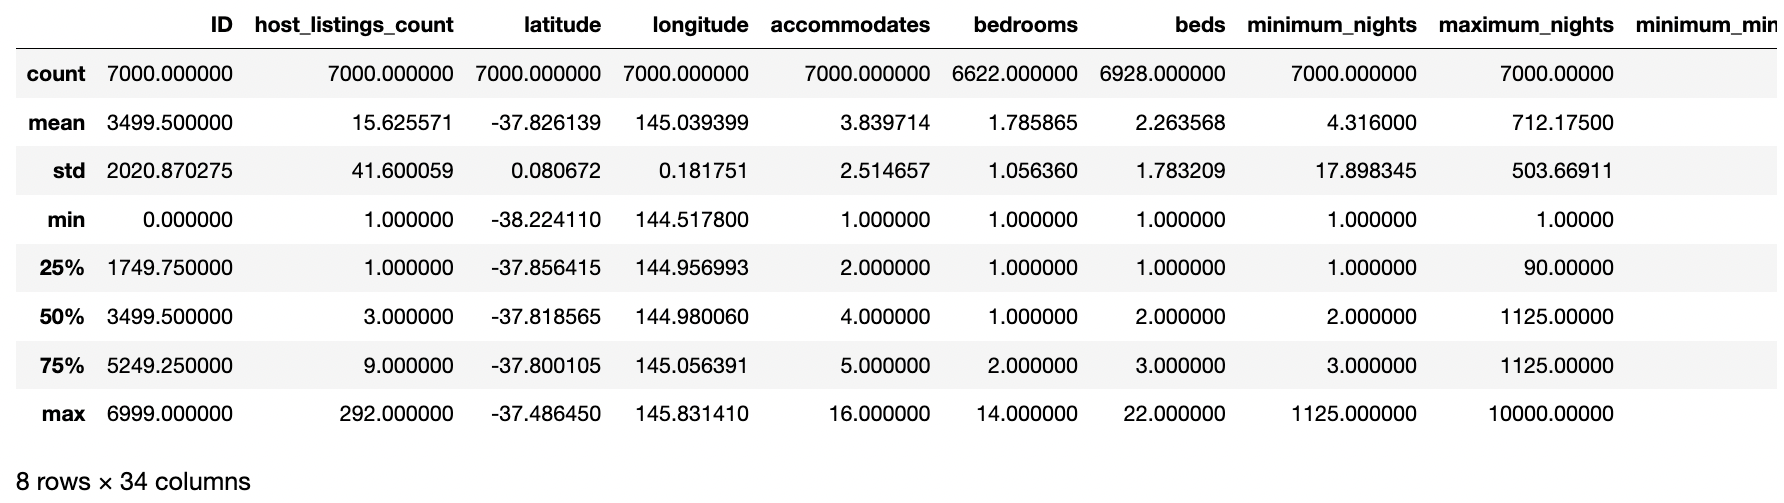



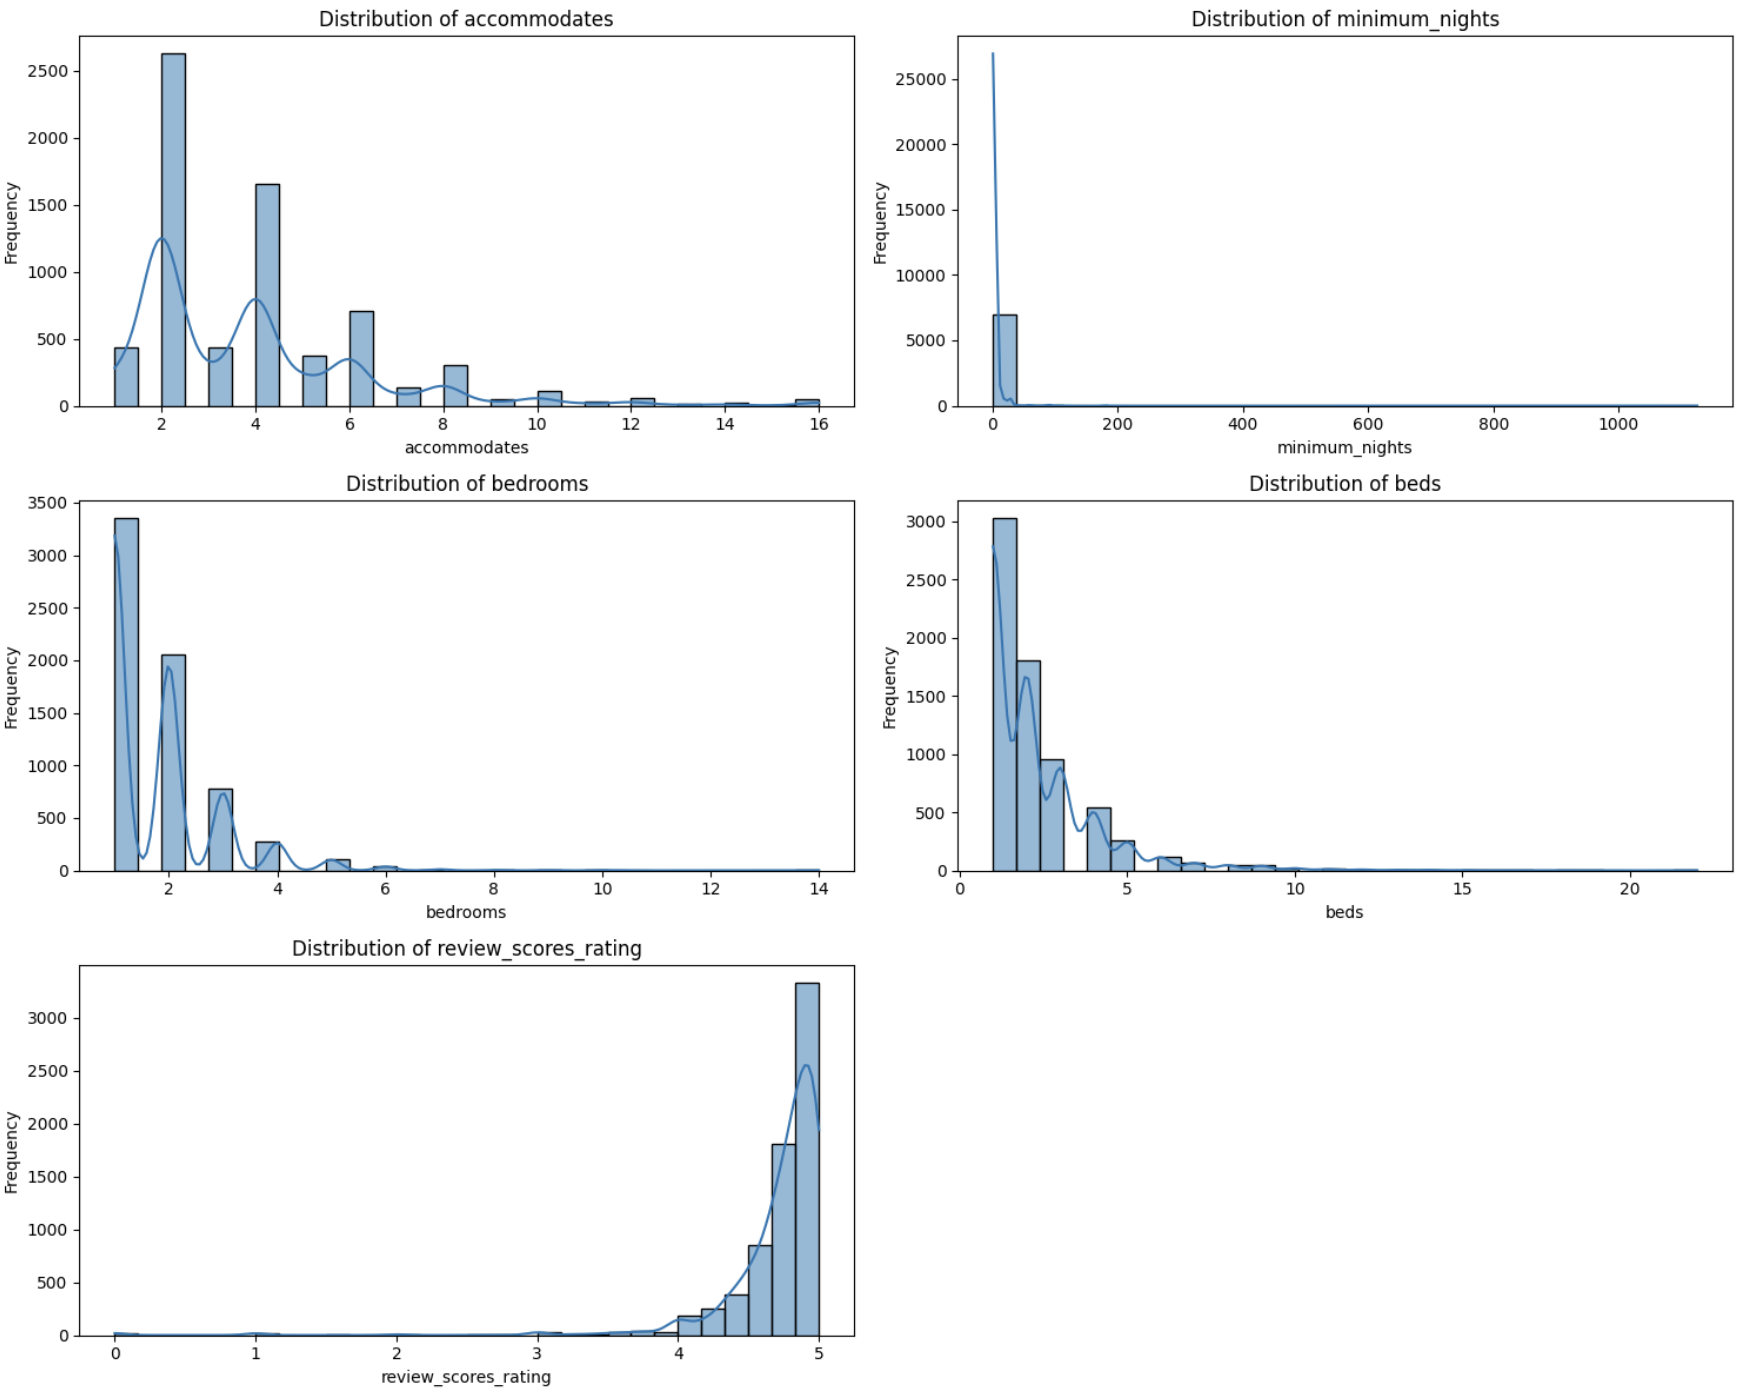

| Variable Kind | Number of Features | Feature Names |
|---------------|---------------------|---------------|
| **Numeric**   | 17                  | calculated_host_listings_count, calculated_host_listings_count_entire_homes, calculated_host_listings_count_private_rooms, calculated_host_listings_count_shared_rooms,<br>host_listings_count, host_acceptance_rate, host_response_rate, ID, latitude, longitude, accommodates, bedrooms, beds, minimum_nights, maximum_nights,  maximum_minimum_nights, minimum_minimum_nights,<br>maximum_maximum_nights, minimum_maximum_nights, minimum_nights_avg_ntm, maximum_nights_avg_ntm, availability_30, availability_60, availability_90, availability_365, <br>number_of_reviews, number_of_reviews_ltm, number_of_reviews_l30d, price |
| **Ordinal**   | 8                   | host_response_time, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value |
| **Nominal**   | 34                  | source, name, description, neighborhood_overview, host_name, host_since, host_location, host_about, host_is_superhost, host_neighbourhood, host_verifications, host_has_profile_pic, host_identity_verified,<br>neighbourhood, neighbourhood_cleansed, property_type, room_type, amenities, has_availability, instant_bookable,  first_review, last_review, bathrooms |

## II: Data Cleaning, Missing Observations and Feature Engineering


### 1. Clean all numerical features so that they can be used in training algorithms. 

In [ ]:
# Check for object-type numerical features in the training dataset
object_columns = train_df.select_dtypes(include='object').columns

# Try to detect which of those might be numerical stored as text, e.g., percentages, dollar values
sample_object_values = train_df[object_columns].iloc[0]

# Print a few example values to manually identify numerical patterns
sample_object_values

In [7]:
# Define function
def clean_numerical_features(df):
    """Clean object-type columns with numerical values."""
    df = df.copy()

    # Convert host_response_rate and host_acceptance_rate to float (remove %)
    for col in ['host_response_rate', 'host_acceptance_rate']:
        if col in df.columns:
            df[col] = df[col].str.rstrip('%').astype(float)

    # Convert 'host_since' to datetime and compute host_tenure in days
    if 'host_since' in df.columns:
        df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce', dayfirst=True)
        today = pd.to_datetime("2025-06-01")
        df['host_days'] = (today - df['host_since']).dt.days

    # Extract number from 'bathrooms'
    if 'bathrooms' in df.columns:
        df['bathrooms'] = df['bathrooms'].str.extract(r'(\d+\.?\d*)').astype(float)

    # Clean 'price': remove $, commas, etc.
    if 'price' in df.columns:
        df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

    return df

# Apply the cleaning to both train and test datasets
train_cleaned = clean_numerical_features(train_df)
test_cleaned = clean_numerical_features(test_df)

# Show result of cleaning on key columns
train_cleaned[['host_response_rate', 'host_acceptance_rate', 'host_days', 'bathrooms', 'price']].head()

<ipython-input-7-be775cb8726a>:13: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce', dayfirst=True)
<ipython-input-7-be775cb8726a>:13: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce', dayfirst=True)


,host_response_rate,host_acceptance_rate,host_days,bathrooms,price
0,100.0,98.0,4460,1.0,132.0
1,100.0,98.0,5737,1.0,39.0
2,100.0,78.0,4934,2.5,270.0
3,75.0,92.0,5467,2.5,1000.0
4,100.0,87.0,5438,1.0,116.0


In this section, I cleaned all relevant numerical features that were originally stored as object (string) types in the dataset. These features could not be used directly in modeling and had to be converted to proper numeric formats.

**`host_response_rate`**
- **Original format:** `"97%"`
- **Cleaned format:** `97.0` (float)
- **Cleaning steps:** Removed the % symbol using .str.rstrip('%') and converted the result to a float using astype(float).

**`host_acceptance_rate`**
- **Original format:** `"100%"`
- **Cleaned format:** `100.0` (float)
- **Cleaning steps:** Same approach as host_response_rate.

**`host_since` ➜ `host_days` (new feature)**
- **Original format:** `"16/3/2013"`
- **Derived Feature:** `host_days`
- **Cleaning steps:** Parsed the date string into a datetime object and calculated the number of days since a fixed reference date (`2025-06-01`).

**`bathrooms`**
- **Original format:** `"1 bath"` or `"2.5 baths"`
- **Cleaned format:** `1.0`, `2.5`, etc. (float)
- **Cleaning steps:** Used a regular expression str.extract(r'(\d+\.?\d*)') to extract the numeric portion of the string, then converted to float.

**`price`**
- **Original format:** `"$1,234.00"`
- **Cleaned format:** `1234.0` (float)
- **Cleaning steps:** Removed dollar signs and commas using a regular expression, then converted the string to a float.

These cleaning steps were critical for ensuring that all numeric values could be interpreted correctly by the model. Without this conversion, string values would break training functions or be ignored altogether.

### 2. Feature Engineering from existing features.   

In [ ]:
# Initialise VADER Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

# Haversine Function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # Radius of Earth in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    return R * c

# Main Feature Engineering pipeline
def engineer_features(df):
    df = df.copy()

    # 1. High- and low-price LGAs based on known suburb patterns
    high_price_lgas = ["Boroondara", "Yarra Ranges", "Stonnington", "Port Phillip", "Melbourne", "Yarra", "Glen Eira", "Bayside", "Whitehorse", "Monash"]
    mix_price_lgas= ["Moreland", "Darebin", "Moonee Valley", "Manningham", "Maribyrnong", "Kingston", "Banyule", "Hobsons Bay"]
    low_price_lgas = ["Brimbank", "Cardinia", "Casey", "Frankston", "Hume", "Melton", "Whittlesea", "Wyndham", "Greater Dandenong", "Nillumbik", "Maroondah", "Knox"]
    df['suburb_price_level'] = df['neighbourhood_cleansed'].apply(
    lambda x: 'high' if x in high_price_lgas else (
        'low' if x in low_price_lgas else (
            'mid' if x in mix_price_lgas else 'other'
        )
    )
)

    # 2. Location cluster (KMeans on lat/long)
    valid_coords = df[['latitude', 'longitude']].dropna()
    kmeans = KMeans(n_clusters=5, random_state=42)
    df.loc[valid_coords.index, 'location_cluster'] = kmeans.fit_predict(valid_coords)

    # 3. Distance to CBD and Beach (from https://stackoverflow.com/questions/27928/calculate-distance-between-two-latitude-longitude-points-haversine-formula)
    cbd_coords = (-37.8136, 144.9631)
    beach_coords = (-37.8676, 144.9780)
    df['dist_cbd'] = df.apply(lambda row: haversine(row['latitude'], row['longitude'], *cbd_coords), axis=1)
    df['dist_beach'] = df.apply(lambda row: haversine(row['latitude'], row['longitude'], *beach_coords), axis=1)

    # 4. Review activity level
    df['reviews_per_month'] = pd.to_numeric(df['reviews_per_month'], errors='coerce')
    df['reviews_activity_level'] = pd.cut(
        df['reviews_per_month'],
        bins=[-1, 0, 1, 3, 10],
        labels=['None', 'Low', 'Medium', 'High']
    )

    # 5. Amenity Features
    luxury_keywords = ['BBQ', 'bathtub', 'fireplace', 'pool', 'cable TV', 'patio']
    basic_keywords = ['lockbox', 'luggage drop off', 'essentials', 'kitchen', 'hot water']

    df['amenity_count'] = df['amenities'].astype(str).apply(lambda x: len(x.split(',')) if x else 0)
    df['cnt_luxury_amenities'] = df['amenities'].astype(str).apply(
        lambda x: sum(kw.lower() in x.lower() for kw in luxury_keywords)
    )
    df['cnt_basic_amenities'] = df['amenities'].astype(str).apply(
        lambda x: sum(kw.lower() in x.lower() for kw in basic_keywords)
    )

    # 6. Host experience (in years)
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_experience_years'] = ((pd.to_datetime('2025-06-01') - df['host_since']).dt.days / 365).fillna(0)

    # 7. Property size index
    df['property_size'] = df[['accommodates', 'bedrooms', 'beds']].sum(axis=1)

    # 8. Host power score
    df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce')
    df['host_listings_count'] = pd.to_numeric(df['host_listings_count'], errors='coerce')
    df['host_power_score'] = (df['host_response_rate'] * df['host_listings_count']).fillna(0)

    # 9. Sentiment from description
    df['description'] = df['description'].astype(str)
    df['description_sentiment'] = df['description'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
    df['description_length'] = df['description'].apply(len)

    # 10. Host property count (sum of rooms)
    df['host_property_count'] = (
        df.get('calculated_host_listings_count_entire_homes', 0).fillna(0) +
        df.get('calculated_host_listings_count_private_rooms', 0).fillna(0) +
        df.get('calculated_host_listings_count_shared_rooms', 0).fillna(0)
    )

    return df

# Apply
train_engineered = engineer_features(train_cleaned)
test_engineered = engineer_features(test_cleaned)

# Display sample of new features
train_engineered[[
    'suburb_price_level',
    'location_cluster',
    'dist_cbd',
    'dist_beach',
    'reviews_activity_level',

    'amenity_count',
    'cnt_luxury_amenities',
    'cnt_basic_amenities',

    'host_experience_years',
    'property_size',
    'host_power_score',
    'description_sentiment',
    'host_property_count'

]].head(10)

,suburb_price_level,location_cluster,dist_cbd,dist_beach,reviews_activity_level,amenity_count,cnt_luxury_amenities,cnt_basic_amenities,host_experience_years,property_size,host_power_score,description_sentiment,host_property_count
0,high,0.0,2.490997,5.366810,High,38,0,3,12.219178,4.0,200.0,0.9877,2
1,mid,0.0,5.479357,11.291512,Medium,57,2,3,15.717808,4.0,100.0,0.3818,1
2,high,1.0,39.223422,36.790282,Low,21,2,2,13.517808,10.0,200.0,0.9445,2
3,high,0.0,0.947826,5.206708,Low,13,0,1,14.978082,4.0,300.0,-0.5267,1
4,other,2.0,42.695092,38.056555,Medium,49,4,3,14.898630,11.0,100.0,0.9558,1
5,high,3.0,18.873964,14.623254,Low,20,0,3,12.216438,3.0,540.0,0.0000,6
6,high,0.0,6.268844,0.296897,Low,9,0,2,13.279452,4.0,300.0,0.9674,2
7,high,0.0,0.746558,6.427706,Medium,26,1,3,13.295890,4.0,300.0,0.8807,1
8,low,4.0,18.385337,21.511257,Medium,41,1,4,13.443836,16.0,1600.0,0.9118,9
9,high,3.0,16.372334,12.494226,Medium,60,2,4,14.838356,4.0,400.0,0.8494,3


In this step, I created additional features based on domain knowledge and insights.

**Summary Table: Engineered Features**

| Theme             | New Feature Name         | Description                                                                 |
|------------------|--------------------------|-----------------------------------------------------------------------------|
| *Location*      | suburb_price_level     | Categorises suburb into high, mid, or low price tier based on known LGA patterns |
|                   | dist_cbd, dist_beach | Haversine distance to Melbourne CBD and St Kilda Beach                      |
|                   | location_cluster       | Cluster label from KMeans based on geographic coordinates (latitude, longitude) |
| *Host Behavior* | host_experience_years  | Number of years since the host joined Airbnb (host_since)                |
|                   | host_property_count    | Sum of entire, private, and shared listings managed by the host            |
|                   | host_power_score       | Product of host_response_rate and host_listings_count (proxy for professionalism) |
| *Property Size* | property_size          | Combined count of accommodates, bedrooms, and beds                    |
| *Amenities*     | amenity_count          | Total number of amenities listed in the property                           |
|                   | cnt_luxury_amenities   | Number of luxury amenities (e.g., BBQ, bathtub, fireplace, pool)           |
|                   | cnt_basic_amenities    | Number of essential amenities (e.g., kitchen, hot water, essentials)       |
| *Text Analysis* | description_sentiment  | Sentiment polarity score of the listing description using VADER            |
|                   | description_length     | Number of characters in the description text                               |
| *Review Info*   | reviews_activity_level | Categorical review frequency level based on reviews_per_month            |

All of the above features were derived using domain knowledge and applied to both train_cleaned and test_cleaned datasets.



These engineered features aim to capture richer information from existing fields that contain embedded or complex data such as amenities and text descriptions.

**Engineered Features**

**suburb_price_level**
- *What it captures:* A categorical indicator of the suburb’s price tier (high, mid, low).
- *Purpose:* Property location is one of the strongest predictors of price. This variable captures known Melbourne price bands using suburb patterns.
- *Method:* Mapped each suburb (neighbourhood_cleansed) into a price level based on external real estate insights.

**host_experience_years**
- *What it captures:* How long the host has been active on Airbnb.
- *Purpose:* More experienced hosts tend to have better reviews and pricing strategies.
- *Method:* Converted host_since to datetime and calculated the number of years since listing.

**property_size**
- *What it captures:* A single metric for the size of the property.
- *Purpose:* Larger properties often command higher prices.
- *Method:* Summed values from accommodates, bedrooms, and beds.

**amenity_count, cnt_luxury_amenities, cnt_basic_amenities**
- *What they capture:*
  - amenity_count: Total number of amenities listed.
  - cnt_luxury_amenities: Number of high-end amenities.
  - cnt_basic_amenities: Number of essential amenities.
- *Purpose:* Reflects property quality and comfort level. Luxury amenities can justify higher prices; basic ones ensure guest expectations are met.
- *Method:*
  - Parsed the amenities string list.
  - Counted matches using keyword sets:
    - *Luxury:* 'BBQ', 'bathtub', 'fireplace', 'pool', 'cable TV', 'patio'
    - *Basic:* 'lockbox', 'luggage drop off', 'essentials', 'kitchen', 'hot water'

**host_power_score**
- *What it captures:* A composite score of host responsiveness and listing count.
- *Purpose:* High-performing, professional hosts may price more effectively.
- *Method:* Multiplied host_response_rate by host_listings_count.

**dist_cbd, dist_beach**
- *What they capture:* Distance to Melbourne CBD and St Kilda Beach (in km).
- *Purpose:* Proximity to key landmarks often influences price.
- *Method:* Applied the haversine formula on latitude and longitude pairs.

**location_cluster**
- *What it captures:* A spatial grouping of listings based on coordinates.
- *Purpose:* Captures regional pricing effects not covered by named suburbs.
- *Method:* Applied KMeans clustering on latitude and longitude.

**description_sentiment**
- *What it captures:* Sentiment score of the listing description.
- *Purpose:* Listings with positively worded descriptions may perform better.
- *Method:* Used VADER sentiment analyzer on the description field.

**host_property_count**
- *What it captures:* Number of listings the host manages across all room types.
- *Purpose:* A proxy for host professionalism or scale of operation.
- *Method:* Summed values from:
  - calculated_host_listings_count_entire_homes
  - calculated_host_listings_count_private_rooms
  - calculated_host_listings_count_shared_rooms

**reviews_activity_level**
- *What it captures:* Review frequency level (None, Low, Medium, High).
- *Purpose:* Indicates popularity and booking regularity.
- *Method:* Converted reviews_per_month into 4 bins:
  - "None": 0 or missing  
  - "Low": >0 and ≤1  
  - "Medium": >1 and ≤3  
  - "High": >3

**Summary**
These features transform noisy or raw data into interpretable, high-signal predictors that help improve model performance. All transformations were applied to both the training and test datasets to maintain consistency and are now ready for modeling.

### 3. Impute the missing values for all features in both the training and test datasets.   

In [9]:
# Inspect missing values in train_engineered before imputing
# Display all rows and shows missing values
pd.set_option('display.max_rows', None)
train_engineered.isnull().sum()

,0
ID,0
source,0
name,1
description,0
neighborhood_overview,1823
host_name,0
host_since,0
host_location,1280
host_about,2270
host_response_time,0


In [10]:
# Inspect missing values in test_engineered before imputing
# Display all rows and shows missing values
pd.set_option('display.max_rows', None)
test_engineered.isnull().sum()

,0
ID,0
source,0
name,0
description,0
neighborhood_overview,1424
host_name,0
host_since,0
host_location,770
host_about,1441
host_response_time,737


In [ ]:
# Define function to handle missing data
def impute_missing_values(df):
    df = df.copy()

    # Impute host-related categorical and numerical info using host_name grouping
    host_cat = ['host_location', 'host_about', 'host_neighbourhood']
    host_num = ['host_acceptance_rate']
    df['host_name'] = df['host_name'].astype(str).str.strip()

    for col in host_cat:
        df[col] = df.groupby('host_name')[col].transform(lambda x: x.ffill().bfill()).infer_objects(copy=False)
        df[col] = df[col].fillna(df[col].mode().iloc[0])

    for col in host_num:
        df[col] = df.groupby('host_name')[col].transform(lambda x: x.ffill().bfill()).infer_objects(copy=False)
        df[col] = df[col].fillna(df[col].median())

    # Review scores grouped by property name
    review_cols = ['review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                   'review_scores_communication', 'review_scores_location', 'review_scores_value']
    for col in review_cols:
        df[col] = df.groupby('name')[col].transform(lambda x: x.fillna(x.median())).infer_objects(copy=False)
        df[col] = df[col].fillna(df[col].median())

    # Impute review activity category
    df['reviews_per_month'] = pd.to_numeric(df['reviews_per_month'], errors='coerce')
    df['reviews_activity_level'] = pd.cut(
        df['reviews_per_month'],
        bins=[-1, 0, 1, 3, 10],
        labels=['None', 'Low', 'Medium', 'High']
    )
    df['reviews_activity_level'] = df.groupby('name')['reviews_activity_level'].transform(
        lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Medium')
    )
    df['reviews_activity_level'] = df['reviews_activity_level'].fillna('Medium')

    # Impute neighbourhood- and room-type related features grouped by property name
    neigh_cat = ['description', 'neighborhood_overview', 'neighbourhood',
                 'neighbourhood_cleansed', 'property_type', 'room_type']
    neigh_num = ['bedrooms', 'beds', 'bathrooms']

    for col in neigh_cat:
        df[col] = df.groupby('name')[col].transform(lambda x: x.ffill().bfill()).infer_objects(copy=False)
        df[col] = df[col].fillna(df[col].mode().iloc[0])

    for col in neigh_num:
        df[col] = df.groupby('host_name')[col].transform(lambda x: x.ffill().bfill()).infer_objects(copy=False)
        df[col] = df[col].fillna(df[col].median())

    # Logic-based fill for numerical ranges
    df['minimum_minimum_nights'] = df['minimum_minimum_nights'].fillna(df.groupby('name')['minimum_nights'].transform('min'))
    df['maximum_maximum_nights'] = df['maximum_maximum_nights'].fillna(df.groupby('name')['maximum_nights'].transform('max'))
    df['availability_365'] = df['availability_365'].fillna(df.groupby('name')['availability_90'].transform('first') * 4)

    # Fill missing names and dates
    df['name'] = df['name'].fillna("Unknown Property")

    if 'first_review' in df.columns:
        df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce', dayfirst=True)
        df['first_review'] = df['first_review'].fillna(df['first_review'].median())

    if 'last_review' in df.columns:
        df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce', dayfirst=True)
        df['last_review'] = df['last_review'].fillna(df['last_review'].median())

    # Final numeric imputation
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    for col in df.select_dtypes(include=['object']).columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode().iloc[0])

    # Auto-detect better data types
    df = df.infer_objects(copy=False)

    return df

# Apply imputation
train_imputed = impute_missing_values(train_engineered)
test_imputed = impute_missing_values(test_engineered)

# Confirm all missing values are handled
print("Missing in train:", train_imputed.isnull().sum().sum())
print("Missing in test:", test_imputed.isnull().sum().sum())

<ipython-input-11-2cdd0b0de6d3>:60: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce', dayfirst=True)
<ipython-input-11-2cdd0b0de6d3>:64: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce', dayfirst=True)


Missing in train: 0
Missing in test: 0


<ipython-input-11-2cdd0b0de6d3>:60: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce', dayfirst=True)


In [12]:
# Inspect missing values in train_engineered after imputing
train_imputed.isnull().sum()

,0
ID,0
source,0
name,0
description,0
neighborhood_overview,0
host_name,0
host_since,0
host_location,0
host_about,0
host_response_time,0


In [13]:
# Inspect missing values in test_engineered after imputing
test_imputed.isnull().sum()

,0
ID,0
source,0
name,0
description,0
neighborhood_overview,0
host_name,0
host_since,0
host_location,0
host_about,0
host_response_time,0


To ensure the dataset is ready for modeling, I performed missing value imputation for both numerical and categorical features using group-based logic and domain knowledge. This step improves model performance by avoiding data loss and reducing the risk of bias due to improper handling of missing data.

**Host Information**
- **Categorical Columns:** `host_location`, `host_about`, `host_neighbourhood`  
  → Forward and backward filled using `host_name` groups, then remaining missing values filled using column mode.
- **Numerical Column:** `host_acceptance_rate`  
  → Forward and backward filled using `host_name`, then remaining missing values filled using the column median.

**Review Scores**
- **Columns:**  
  `review_scores_accuracy`, `review_scores_cleanliness`, `review_scores_checkin`,  
  `review_scores_communication`, `review_scores_location`, `review_scores_value`  
  → Grouped by `name`, missing values filled using the group-wise median. Remaining nulls filled with global median.

**Review Activity Level**
- **Feature:** `reviews_activity_level`  
  → Derived from `reviews_per_month` by binning into:
    - `"None"`: 0 or missing
    - `"Low"`: (0, 1]
    - `"Medium"`: (1, 3]
    - `"High"`: (3, 10]  
  → Grouped by `name`, filled missing values using mode. If no mode exists, default fallback is `'Medium'`.

**Neighbourhood and Property Characteristics**
- **Categorical Columns:**  
  `description`, `neighborhood_overview`, `neighbourhood`,  
  `neighbourhood_cleansed`, `property_type`, `room_type`  
  → Grouped by `name`, applied forward and backward fill, then remaining nulls filled with mode.
- **Numerical Columns:**  
  `bedrooms`, `beds`, `bathrooms`  
  → Grouped by `host_name`, forward/backward filled, then filled with median.

**Logical Imputation Based on Related Features**
- `minimum_minimum_nights`  
  → Filled with the **minimum** of `minimum_nights` for the same property name.
- `maximum_maximum_nights`  
  → Filled with the **maximum** of `maximum_nights` for the same property name.
- `availability_365`  
  → Estimated by multiplying `availability_90` by 4 (approximate annual coverage).

**Date Fields**
- **Columns:** `first_review`, `last_review`  
  → Parsed as datetime with `dayfirst=True`. Missing values filled with the column median.

**Remaining Missing Values**
- **All remaining numeric columns**  
  → Imputed using the median of the column.
- **All remaining object columns**  
  → Imputed using the mode of the column.

**Result**
- **All missing values have been successfully filled.**
- **No columns in the training or test dataset contain NaN values after imputation.**

The datasets are now clean and fully prepared for categorical encoding and modeling in the next step.

### 4. Encode all categorical variables appropriately

In [ ]:
# Define function
def encode_categorical_features(df, top_n=5, exclude_cols=None):
    """
    Encode categorical variables based on rules:
    - Exclude long-text columns from encoding.
    - Convert multi-valued cells to 'other'.
    - For high-cardinality features, keep top N + 'other'.
    - Apply one-hot encoding.
    """
    df = df.copy()

    # Define default excluded columns if none provided
    if exclude_cols is None:
        exclude_cols = ['description','host_about','neighborhood_overview','host_location','name','source','host_name']

    # Identify object-type columns, excluding raw text ones
    cat_cols = [col for col in df.select_dtypes(include='object').columns if col not in exclude_cols]

    for col in cat_cols:
        # Replace entries that contain multiple values with 'other'
        df[col] = df[col].astype(str).apply(lambda x: 'other' if ',' in x or '[' in x or ']' in x else x)

        # Keep top N most frequent categories, others to 'other'
        top_categories = df[col].value_counts().nlargest(top_n).index
        df[col] = df[col].apply(lambda x: x if x in top_categories else 'other')

    # One-hot encode all cleaned categorical columns
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    return df

# Define long-text columns to exclude explicitly
excluded_text_columns = ['description','host_about','neighborhood_overview','host_location','name','source','host_name']

# Apply updated encoding function
train_encoded = encode_categorical_features(train_imputed, exclude_cols=excluded_text_columns)
test_encoded = encode_categorical_features(test_imputed, exclude_cols=excluded_text_columns)

# Align train/test features
common_cols = train_encoded.columns.intersection(test_encoded.columns)
train_encoded = train_encoded[common_cols]
test_encoded = test_encoded[common_cols]

# Preview
pd.set_option('display.max_columns', None)
train_encoded.head()

,ID,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_rate,host_acceptance_rate,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_days,location_cluster,dist_cbd,dist_beach,reviews_activity_level,amenity_count,cnt_luxury_amenities,cnt_basic_amenities,host_experience_years,property_size,host_power_score,description_sentiment,description_length,host_property_count,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,host_is_superhost_t,host_neighbourhood_Central Business District,host_neighbourhood_South Yarra,host_neighbourhood_Southbank,host_neighbourhood_other,host_has_profile_pic_t,host_identity_verified_t,neighbourhood_cleansed_Port Phillip,neighbourhood_cleansed_Stonnington,neighbourhood_cleansed_Yarra,neighbourhood_cleansed_Yarra Ranges,neighbourhood_cleansed_other,property_type_Entire home,property_type_Entire rental unit,property_type_Private room in home,property_type_other,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_t,suburb_price_level_low,suburb_price_level_mid,suburb_price_level_other
0,0,city scrape,"The Stables, Richmond",Superbly located hotel style accommodation in ...,Richmond is a great neighbourhood. A beautifu...,Ione,2013-03-16,"Melbourne, Australia",I'm a working mum who loves being able to shar...,100.0,98.0,2.0,-37.82030,144.99016,2,1.0,1.0,1.0,2,14,2.0,2,1125,1125.0,2.0,1125.0,0,0,0,12.0,741,37,1,2013-03-29,2023-02-18,4.88,4.91,4.97,4.94,4.93,4.93,4.82,2,2,0,0,6.11,4460,0.0,2.490997,5.366810,High,38,0,3,12.219178,4.0,200.0,0.9877,1000,2,False,False,True,False,False,False,False,True,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1,city scrape,Room in Cool Deco Apartment in Brunswick East,A large air conditioned room with firm queen s...,This hip area is a crossroads between two grea...,Lindsay,2009-09-16,"Melbourne, Australia",As an artist working in animation and video I ...,100.0,98.0,1.0,-37.76606,144.97951,2,1.0,1.0,1.0,4,27,4.0,4,27,27.0,4.0,27.0,0,12,22,112.0,169,25,3,2013-01-12,2023-03-08,4.48,4.64,3.97,4.72,4.69,4.65,4.60,1,0,1,0,1.37,5737,0.0,5.479357,11.291512,Medium,57,2,3,15.717808,4.0,100.0,0.3818,1000,1,False,True,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False
2,2,city scrape,The Suite @ Angelus Retreat,<b>The space</b><br />Welcome to ANGELUS Retre...,Melbourne - Voted most livable city in the wor...,Margaret Jiin,2011-11-28,"Melbourne, Australia",I have very special interests in Life and Life...,100.0,78.0,2.0,-37.90546,145.39447,4,2.5,2.0,4.0,2,365,2.0,2,365,365.0,2.0,365.0,30,60,90,365.0,8,2,0,2015-07-06,2022-06-13,4.75,4.88,4.75,4.88,4.50,5.00,4.75,2,2,0,0,0.09,4934,1.0,39.223422,36.790282,Low,21,2,2,13.517808,10.0,200.0,0.9445,1000,2,False,True,False,True,True,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False
3,3,city scrape,Million Dollar Views Over Melbourne,<b>The space</b><br /><b>Enjoy Million Dollar ...,Melbourne - Voted most livable city in the wor...,Paul,2010-06-13,"Melbourne, Australia",Professional couple who enjoy entertaining 

To make categorical variables usable in machine learning models, I applied an encoding strategy that balances dimensionality reduction with preservation of useful signal. The steps below outline my approach and the rationale behind each transformation.

**Encoding Strategy**

| Rule | Description |
|------|-------------|
| **Multi-valued entries** | Any entry containing multiple values (e.g., comma-separated strings or lists) was simplified by labeling it as `'other'`. This prevents sparse feature expansion during one-hot encoding. |
| **High-cardinality columns** | For columns with many unique values, only the top **5 most frequent categories** were retained. All other values were grouped into `'other'`. This helps reduce dimensionality and avoid overfitting. |
| **Exclusion of raw text fields** | Long free-text fields such as `description`, `host_about`, `neighborhood_overview`, `host_location`, `name`, `source`, and `host_name` were excluded from encoding. These fields either: Contain unstructured text that’s already covered by other engineered features (e.g., `description_sentiment`), or Would cause high dimensionality and noise if included. |

**One-hot encoding**
Remaining cleaned categorical columns were one-hot encoded using `pd.get_dummies()`. The first category in each variable was dropped to prevent multicollinearity (`drop_first=True`).

**Output**
- All categorical features have now been converted to numerical format.
- Unseen or rare categories have been grouped as `'other'` to enhance model generalisation.
- The train and test datasets were aligned to share the same column structure after encoding.
- The result is a clean, numeric dataset that is ready for use in regression modeling.
**Post-Encoding Status**
- `train_encoded` and `test_encoded` now contain the **same set of aligned features**.
- Long, unstructured text fields have been safely excluded or previously transformed.
- Dimensionality is controlled while maintaining key categorical signals.

With this step, the dataset is now fully prepared for building and evaluating predictive models in part III.

### 5. Perform additional data preparation 

In [ ]:
# Check for duplicate rows in the training set
duplicate_count = train_encoded.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Check for duplicate rows in the test set
duplicate_count = test_encoded.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0
Number of duplicate rows: 0


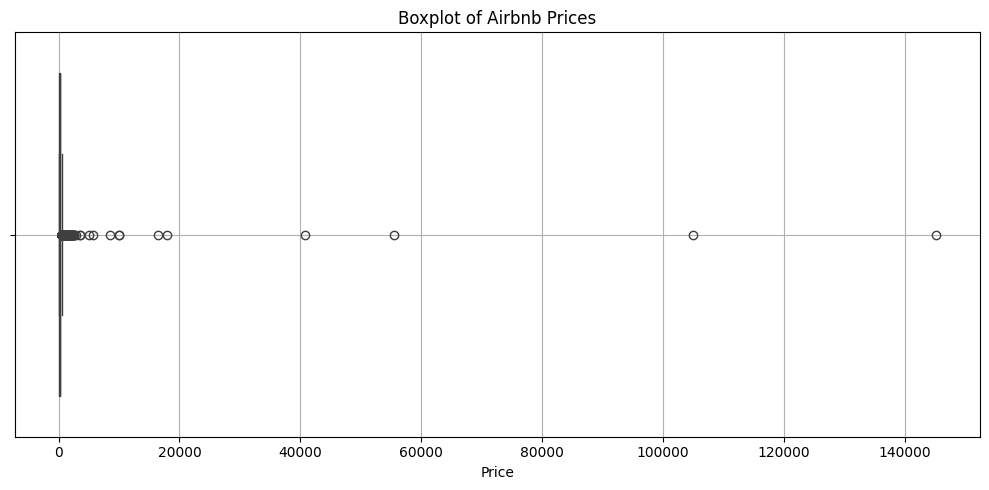

        ID     price
4170  4170  145160.0
3895  3895  104983.0
665    665   55419.0
6838  6838   40844.0
2356  2356   17988.0
2224  2224   16429.0
4722  4722    9999.0
3619  3619    9999.0
4246  4246    8499.0
4484  4484    5750.0
6357  6357    5000.0
6444  6444    3571.0
1327  1327    3540.0
5459  5459    2871.0
944    944    2500.0
5789  5789    2500.0
3242  3242    2500.0
1901  1901    2400.0
4218  4218    2340.0
3628  3628    2206.0

Total outliers: 474


In [16]:
# Create a boxplot of price
plt.figure(figsize=(10, 5))
sns.boxplot(x=train_imputed['price'])
plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price")
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate IQR for outlier detection
Q1 = train_imputed['price'].quantile(0.25)
Q3 = train_imputed['price'].quantile(0.75)
IQR = Q3 - Q1

# Outlier mask
outlier_mask = (train_imputed['price'] < (Q1 - 1.5 * IQR)) | (train_imputed['price'] > (Q3 + 1.5 * IQR))

# Extract ID and price of outliers
outliers = train_imputed.loc[outlier_mask, ['ID', 'price']]

# Show top 20 outliers by price
print(outliers.sort_values(by='price', ascending=False).head(20))
print(f"\nTotal outliers: {len(outliers)}")

In [17]:
# Columns to inspect for outliers
columns_to_check = [
    'maximum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'maximum_nights_avg_ntm'
]

# DataFrame to store all outlier results
outlier_results = pd.DataFrame()

# Loop through each column and collect outliers with their values
for col in columns_to_check:
    Q1 = train_imputed[col].quantile(0.25)
    Q3 = train_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Extract outliers for the column
    mask = (train_imputed[col] < lower) | (train_imputed[col] > upper)
    df_out = train_imputed.loc[mask, ['ID', col]].copy()
    df_out['feature'] = col
    df_out.rename(columns={col: 'outlier_value'}, inplace=True)

    # Append to combined DataFrame
    outlier_results = pd.concat([outlier_results, df_out], ignore_index=True)

# Display outlier table
pd.set_option('display.float_format', '{:.0f}'.format)
print(outlier_results[['ID', 'outlier_value', 'feature']])
print(f"Total outliers found: {len(outlier_results)}")

      ID  outlier_value                 feature
0   2071          10000          maximum_nights
1   2071          10000  minimum_maximum_nights
2   5092     2147483647  minimum_maximum_nights
3   5097           9999  minimum_maximum_nights
4   5103           9999  minimum_maximum_nights
5    860           9999  maximum_maximum_nights
6   2071          10000  maximum_maximum_nights
7   3931           9999  maximum_maximum_nights
8   4983     2147483647  maximum_maximum_nights
9   4987     2147483647  maximum_maximum_nights
10  4989     2147483647  maximum_maximum_nights
11  4990     2147483647  maximum_maximum_nights
12  4992     2147483647  maximum_maximum_nights
13  4993     2147483647  maximum_maximum_nights
14  5050     2147483647  maximum_maximum_nights
15  5088     2147483647  maximum_maximum_nights
16  5089     2147483647  maximum_maximum_nights
17  5090     2147483647  maximum_maximum_nights
18  5092     2147483647  maximum_maximum_nights
19  5097           9999  maximum_maximum

In [18]:
# Drop rows where price > 20000
extreme_price_ids = train_imputed[train_imputed['price'] > 20000]['ID']
print(f"Rows removed with price > 20000: {len(extreme_price_ids)}")

# Drop extreme night outlier IDs
night_outlier_ids = [
    2071, 5092, 5097, 5103, 860, 3931, 4983, 4987, 4989, 4990, 4992,
    4993, 5050, 5088, 5089, 5090
]
night_outlier_ids = list(set(night_outlier_ids))
print(f"Rows removed due to night-based extreme outliers: {len(night_outlier_ids)}")

# Combine unique IDs to drop
all_drop_ids = pd.Series(list(set(extreme_price_ids).union(set(night_outlier_ids))))

# Drop from imputed and encoded datasets
train_imputed_clean = train_imputed[~train_imputed['ID'].isin(all_drop_ids)].reset_index(drop=True)
train_encoded_clean = train_encoded[~train_encoded['ID'].isin(all_drop_ids)].reset_index(drop=True)

print(f"Total rows removed (unique IDs): {len(all_drop_ids)}")

Rows removed with price > 20000: 4
Rows removed due to night-based extreme outliers: 16
Total rows removed (unique IDs): 20


In [19]:
# Final data preparation for modeling
def final_preparation(train_imputed_df, train_encoded_df, test_encoded_df, target_col='price', id_col='ID'):
    """
    Prepares final datasets for modeling:
    - Extracts y_train from imputed data.
    - Drops target column from train_encoded (keeps ID).
    - Aligns features between train and test.
    """
    y_train = train_imputed_df[target_col]
    drop_cols = [target_col] if target_col in train_encoded_df.columns else []
    train_encoded_df = train_encoded_df.drop(columns=drop_cols)

    common_cols = train_encoded_df.columns.intersection(test_encoded_df.columns)
    X_train = train_encoded_df[common_cols]
    X_test = test_encoded_df[common_cols]

    return X_train, y_train, X_test

# Apply final prep on cleaned datasets
X_train, y_train, X_test = final_preparation(train_imputed_clean, train_encoded_clean, test_encoded)

# Confirm shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (6980, 87)
y_train shape: (6980,)
X_test shape: (3000, 87)


In [20]:
# Create copies to test outlier removal if removed all outlier
train_imputed_copy = train_imputed.copy()
train_encoded_copy = train_encoded.copy()

# 1. Identify IQR-based outliers from train_imputed_copy
Q1 = train_imputed_copy['price'].quantile(0.25)
Q3 = train_imputed_copy['price'].quantile(0.75)
IQR = Q3 - Q1

# 2. Create outlier mask
outlier_mask = (train_imputed_copy['price'] < (Q1 - 1.5 * IQR)) | (train_imputed_copy['price'] > (Q3 + 1.5 * IQR))

# 3. Get IDs of outlier rows
outlier_ids = train_imputed_copy.loc[outlier_mask, 'ID']

# 4. Filter out outliers from the copies
train_imputed_test = train_imputed_copy[~train_imputed_copy['ID'].isin(outlier_ids)].reset_index(drop=True)
train_encoded_test = train_encoded_copy[~train_encoded_copy['ID'].isin(outlier_ids)].reset_index(drop=True)

# Compare shapes
print("Original shape:", train_imputed_copy.shape)
print("Test Cleaned shape:", train_imputed_test.shape)
print("Outliers removed:", len(outlier_ids))

Original shape: (7000, 76)
Test Cleaned shape: (6526, 76)
Outliers removed: 474


In [21]:
# Confirm the final data is unchanged
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (6980, 87)
y_train shape: (6980,)
X_test shape: (3000, 87)


In this step, I have ensured that the training and test datasets are fully ready for modeling.

**Check Point: Duplicate Records**

I checked for duplicate entries in both the training and test datasets using the `.duplicated().sum()` method.

- **Duplicate rows found in training set:** 0  
- **Duplicate rows found in test set:** 0  
- **Action taken:** No action needed, as no duplicates were present.

**Check Point: Outliers in Target and Feature Columns**

I visualised the target variable (`price`) using a boxplot and performed outlier detection based on the IQR method.

- **Boxplot:** Revealed a long right tail with some extreme values.
- **IQR Rule Applied to `price`:**  
  Outliers were defined as values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.
- **Extreme Business Rule:** All listings with price > 20,000 were dropped.  
- **Night-related Outliers:** Listings with unrealistically high values in the following columns were also dropped:
  - `maximum_nights`
  - `minimum_maximum_nights`
  - `maximum_maximum_nights`
  - `maximum_nights_avg_ntm`

A total of **20 rows** were removed based on these combined filters.

**Final Cleanup Actions**

- **Target Extraction:** The `price` column was extracted from `train_imputed_clean` to form `y_train`.
- **ID Columns Preserved:** I did not drop the `ID` column in this phase to support later model ID tracking, if needed.
- **Column Alignment:** Used `.intersection()` to ensure `X_train` and `X_test` had the same features after encoding.
    - y_train was extracted from the price column of train_imputed.
- **Final Clean Datasets:**  
  Cleaned versions of both imputed and encoded datasets were used to create the final `X_train`, `y_train`, and `X_test`.

**Final Dataset Shapes**

| Dataset     | Rows | Columns |
|-------------|------|---------|
| `X_train`   | 6980 | 87      |
| `y_train`   | 6980 | 1       |
| `X_test`    | 3000 | 87      |

**Conclusion**

All critical data preparation steps—duplicate removal, outlier handling, and feature alignment—are now complete.  
Our final datasets are clean, consistent, and ready to be used for modeling tasks such as linear regression, decision trees, random forest, ridge, etc.

## III: Fit and tune predictive models, submit predictions & win competition


### 1. EDA to measure the relationship between the features and the target variable


The barchart shows the relationship between the suburbs and the Airbnb price for the listings. For the sake of intepretability,
we only filter out the top 10 neighbourhoods in average Airbnb price. As demonstrated by the graph, we can see that the suburb
that is most highly priced is Balaclava, Victoria, Australia with an average property price of $1500.00. This makes logical sense,
as Balaclava is close to Port Phillip beach, and is home to many bustling businesses, such as cafe, shops and has great walkability score.
Following Balaclava, we have Steels Creek, Victoria, with an average price of $1000.00. This area is situated in the more mountainous area
of Victoria, and is known to be a detination offering a blend of natural scenery, historical significance and outdoor activities.
The middle-tier properties include Hoddles Creek, Yering, Hawthron, Yarra Junction and Dixon Creek, with an average price ranging from $900.00
to $800.00. At the bottom of the list, we have Meadow Heights,

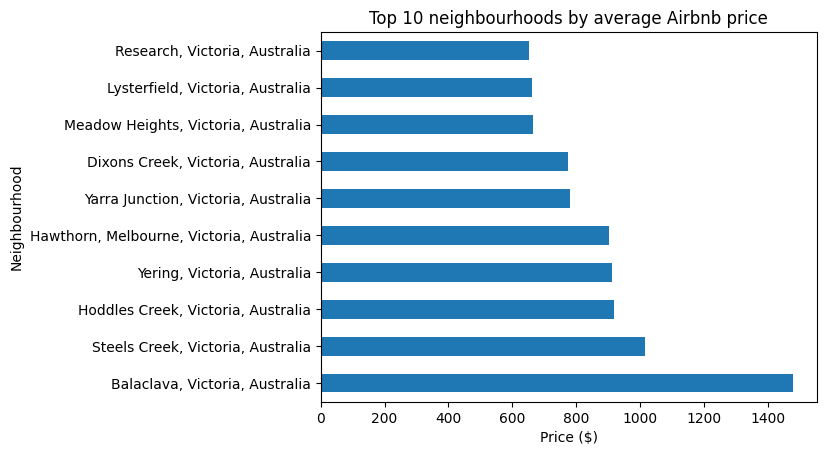

In [ ]:
# Graphing the price of Airbnb groupby neighbourhood
train_imputed_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 neighbourhoods by average Airbnb price')
plt.xlabel('Price ($)')
plt.ylabel('Neighbourhood')

The barchart shows the relationship between the suburbs and the Airbnb price for the listings. For the sake of intepretability, we only filter out the top 10 neighbourhoods in average Airbnb price. As demonstrated by the graph, we can see that the suburb that is most highly priced is Balaclava, Victoria, Australia with an average property price of $1500.00. This makes logical sense, as Balaclava is close to Port Phillip beach, and is home to many bustling businesses, such as cafe, shops and has great walkability score.

Following Balaclava, we have Steels Creek, Victoria, with an average price of $1000.00. This area is situated in the more mountainous area of Victoria, and is known to be a detination offering a blend of natural scenery, historical significance and outdoor activities.

The middle-tier properties include Hoddles Creek, Yering, Hawthron, Yarra Junction and Dixon Creek, with an average price ranging from $900.00 to $800.00. At the bottom of the list, we have Meadow Heights, Lysterfield and Research. The all positioned in the outer suburbs of Melbourne, and is known to offer larger lodge or villas suitable for large group hosting. These areas has the same average price of $700.00.

Overall, we can definitely see that neighbourhood has a strong impact on price. 

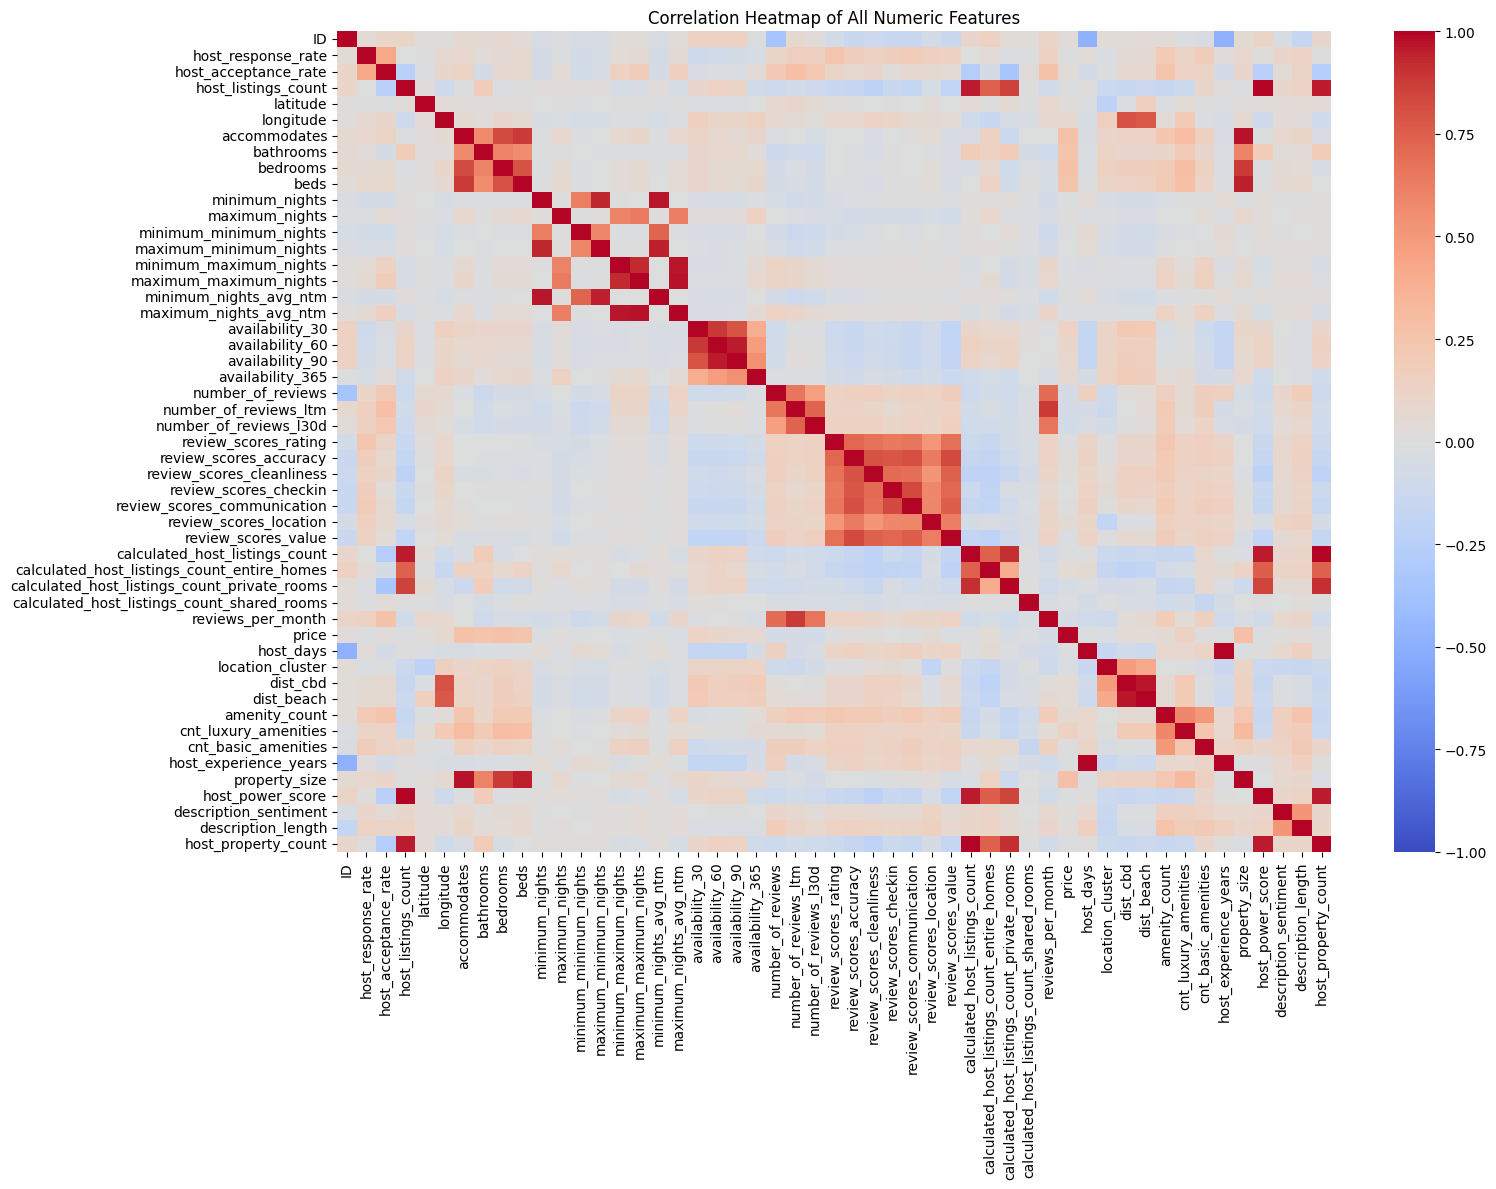

The graph illustrates the correlation between numerical features and the target variable, price. As shown, there is a strong
positive correlation with variables such as accommodates, bathrooms, bedrooms, and beds. This is expected, as properties that can
accommodate larger groups and offer more facilities tend to be priced higher due to the increased value and comfort they provide.
Similarly, property_size also demonstrates a strong positive correlation, reinforcing the idea that larger properties are associated
with higher prices. In contrast, most other features exhibit weak to neutral correlations with price, suggesting they may have limited
direct impact on pricing and could be less influential in predictive modeling.


In [ ]:
# Select only numeric columns
numeric_df = train_imputed_clean.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot the full heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of All Numeric Features')
plt.tight_layout()
plt.show()

The graph illustrates the correlation between numerical features and the target variable, price. As shown, there is a strong positive correlation with variables such as accommodates, bathrooms, bedrooms, and beds. This is expected, as properties that can accommodate larger groups and offer more facilities tend to be priced higher due to the increased value and comfort they provide.

Similarly, property_size also demonstrates a strong positive correlation, reinforcing the idea that larger properties are associated with higher prices. In contrast, most other features exhibit weak to neutral correlations with price, suggesting they may have limited direct impact on pricing and could be less influential in predictive modeling.

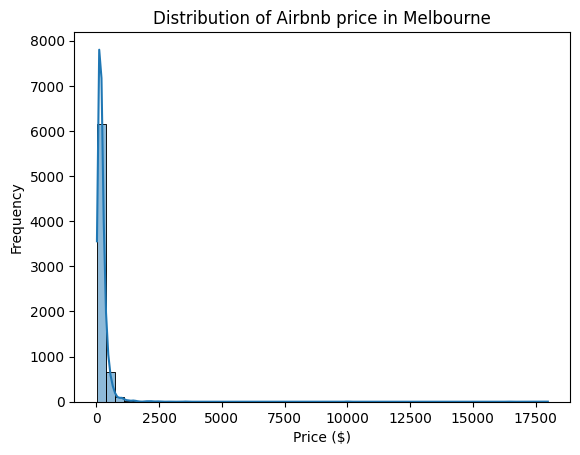


Initial investigation suggests that price are highly right skewed. This align with our assumption that most properties will have a lower price, and only a few outliers will
have significant higher values. However, this distribution can distort the assumption or normality in linear regressions. To address this challenge, we will apply log transformation
using np.log1p(price) in the future steps. This transformation will stabilise variance and improve model's generalisation capacity.


In [ ]:
sns.histplot(train_imputed_clean['price'], bins=50, kde=True)
plt.title('Distribution of Airbnb price in Melbourne')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

Initial investigation suggests that price are highly right skewed. This align with our assumption that most properties will have a lower price, and only a few outliers will have significant higher values. However, this distribution can distort the assumption or normality in linear regressions. To address this challenge, we will apply log transformation using np.log1p(price) in the future steps. This transformation will stabilise variance and improve model's generalisation capacity.

### 2. The ML models that I will be using

For this competition, I selected 3 ML models: Ridge Regression, Decision Tree Regression and XGBoost Regression. My aim is to correctly predict the Airbnb price in Melbourne, evaluated by MAE. Thw dataset has many features, including numerical features, ordinal features and nominal features, as identified in part I. By choosing these models, I aim to provide a balanced and comprehensive modelling approach, capturing both the linear trends, along with the complex non-linear interaction within the dataset.

Firstly, Ridge Regression is an extension of linear regression. The model use L2 regularisation, which penalise large coefficients. This helps to reduce model complexity and prevent overfitting. In the situation of my dataset, there are a lot of features and possible multicollinearity, for example beds, review scores or count of luxury amenities (cnt_luxury_amenities). This is a common observation in the real-estate indutry, and employing the Ridge Regression will act as a strong baseline model that interpret price increases or decreases with each features. A note for this model is that the Ridge Regressor would require the data to be normally distributed, therefore, I will conduct feature transformation in the next step.

The Decision Tree Regressor is a model that does not require the assumption that data has to be normally distributed. It will iteratively split nodes until the leaves are pure or a stopping criterion is statisfied. This approach allows the model to cature abrupt changes in price and understand the interconnected relationship between these variables that might be missed if we employ a linear model. For example, the impact of room_type on price might be different based on the neighbourhood that the property is in, such as rooms in Melbourne CBD will be more expensive than those in the outskirt of the city. Additionally, the model is also easy to interpret, making it useful to indeitfying the most important variables that contributes to the changes of prices. A note for this model is that we need to choose an appropriate depth of the tree so as not to overfit or underfit.

Lastly, I employ the XGBoost Regression. This is a powerful machine learning model that implements gradient boosting algorithm. Employing XGBoost is a good choice, as this model can capture non-linearities, understand interaction between features and is robust to noises in the dataset. Additionally, we can easily interpret the importance of features in the mode, making it useful to understand the drivers behind the Airbnb price in Melbourn. Given the complex nature of our dataset, this model offers the robustness and flexibility needed to accurately predict Melbourne Airbnb price.

### 3. Training the models

For the initial model testing, based on my existing assumptions, I will start by including the following features:

- bedrooms: Property with more bedrooms should have higher prices as they offer more space for larger groups.
- accomodates: We assume that properties that can accomodate larger groups will likely to be priced higher, as it offers more capacity and values for group booking.
- minimum_minimum_nights: We assume that a property with small minimum minimum night, for example 1 or 2 nights, will mean that it has higher flexibiity, and can cost more due to this added benefit.
- bathrooms: More bathrooms will make the guests more comfortable, especially for larger groups, and can potentially increase the price.
- beds: More beds will mean more capacity for larger groups, and directly increase its price.
- review_scores_rating: We assume that property with high review scores will be more expensive due to its popularity and high demand from customers.
- amenity_count: Apart from luxury amenities, properties are also likely to be priced higher if they offer more amenities to clients.
- cnt_luxury_amenities: A property with more luxury amentities will have higher price due to the added benefits and facilities that it offers.
- cnt_basic_amenities: Basic amenities are neccessary for a comfortable stay at the property. A well-equiped Airbnb will have a higher price.
- host_property_count: Experienced host can create better experience for their customers. This may lead to higher prices.

In [26]:
# Set scorer for MAE for grid search - the lower the MAE is, the better
mae_evaluation = make_scorer(MAE, greater_is_better=False)

In [27]:
# Select specific columns in X_train, X_test
X_train_selected = X_train[['bedrooms', 'accommodates', 'minimum_minimum_nights', 'bathrooms', 'beds', 'review_scores_rating', 'amenity_count', 'cnt_luxury_amenities', 'cnt_basic_amenities', 'host_property_count']]
X_test_selected = X_test[['bedrooms', 'accommodates', 'minimum_minimum_nights', 'bathrooms', 'beds', 'review_scores_rating', 'amenity_count', 'cnt_luxury_amenities', 'cnt_basic_amenities', 'host_property_count']]

# Standardise X_train_selected and X_test_selected
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_selected)
X_test_scaled = scaler_X.transform(X_test_selected)

In [ ]:
# Optimise Ridge with  GridSearch CV
ridge = Ridge(alpha = 0.1)
alpha_param_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 150, 200]}               # Different alpha values for GridSearchCV

grid_ridge = GridSearchCV(estimator = ridge,
                          param_grid = alpha_param_ridge,                                 # Goes through the dictionary with different alpha values
                          scoring = mae_evaluation,                                       # Evaluate MAE with MAE smaller is better
                          cv = KFold(n_splits=5, shuffle = True, random_state = 42),       # 5-fold cross validation, randomly shuffle the data before splitting and set random state = 1
                          n_jobs = -1                                                     # Use all available CPU cores to speed up the process
)

grid_ridge.fit(X_train_scaled, y_train)
print(f'Best Ridge Alpha: {grid_ridge.best_params_["alpha"]}')
print(f'Best Ridge MAE on training set: {-grid_ridge.best_score_:.3f}')

# Use best estimator from grid search
best_ridge = grid_ridge.best_estimator_

# Inspect feature weights of Ridge
coefficients_ridge = pd.Series(best_ridge.coef_, index= X_train_selected.columns)
print('Fitted weight of Ridge model ranking from positive to negative')
print(coefficients_ridge.sort_values(ascending=False))


Best Ridge Alpha: 200
Best Ridge MAE on training set: 108.727
Fitted weight of Ridge model ranking from positive to negative
bathrooms                 54
accommodates              51
bedrooms                  37
cnt_luxury_amenities      31
minimum_minimum_nights    -4
review_scores_rating      -5
beds                      -7
cnt_basic_amenities      -11
host_property_count      -11
amenity_count            -16
dtype: float64

Interpretation:

Fitted Weight:
Looking at the weights of the features, we can understand how they influence the predicted price. Larger weights indicate more influence, and the negative or positive sign shows the direction
of the relationship. We observe that the most influential feature is bathrooms, with a coefficient of approximately 59.70. This shows a strong positive correlation with price, indicating that
properties with more bathrooms will improve guests' comfort, increasing Airbnb price. Following this, we have accomodates with a coefficient of 50.66 sho

**Interpretation:**

**Fitted Weight:**

Looking at the weights of the features, we can understand how they influence the predicted price. Larger weights indicate more influence, and the negative or positive sign shows the direction of the relationship. We observe that the most influential feature is bathrooms, with a coefficient of approximately 59.70. This shows a strong positive correlation with price, indicating that properties with more bathrooms will improve guests' comfort, increasing Airbnb price. Following this, we have accomodates with a coefficient of 50.66 showing positive correlation. This aligns with our previous assumption that properties that can house larger groups will have higher price. Other positively correlated features are bedrooms and cnt_luxury_amenities both with moderate coefficients, at 36.51 and 31.31 respectively. This also align with our assumptions that properties with more bedrooms and more luxury items will be able to accomodate larger guest groups, and provide them with more luxury services, thus, adding to their listing prices.

On the other hand, we have 6 features that shows negative relationship to price, and they are minimum_minimum_nights, review_scores_rating, beds, cnt_basic_amenities, host_property_count and amenity_count. amenity_count has the most negative coefficient to price (-16.44), which means that once a property reaches a certain amounts of amenties, adding more might have a negative impact on price, contrasting with our assumption made prior to fitting the model. host_property_price and cnt_basic_amenities have a coefficient of -11.40 and -10.82 respectively. This might suggest that hosts manging multiple properties might focus on hostle, shared rooms, cheap houses, and that having too many basic amenities can potentially cheapens the property price. minimum_minimum_nights, review_scores_rating and beds have low fitted weights of -3.93, -4.91 and -7.05. This paints the picture that property that requires higher minimum required stay, having more beds and higher ratings will have lower price. The coefficient for minimum_minimum_nights makes sense logically, because people who rent Airbnb are often after short stays or going on holiday so a longer locked-in period of time might make the properties less attractive to them. Additionally, adding more beds (eg: sofa beds, inflatable beds), can potentially cheapens the property price, as this might mean the room is shared, or the property might be a dorm rooms. However, surpringly higher review score are associated with slightly lower prices in our model. This might be because cheaper properties might try to get better reviews, or might be because of multicolinearity, which means the feature might be redundant, hence our Ridge model penalty it. As this model actw as a base-line for us, further inspection and tuning will be done in the next steps to address this issue.

**Optimised parameter:**

Using 5-fold GridSearCV, we have an alpha of 200. This is a relatively large value, symbolising strong regularisation strength. This means the model can benefit from significant shrinkage
of its coefficients.

**Training dataset predictive performance:**

The best MAE on our training dataset is 108.727. This means that comparing to the actual price, our model's prediction was $108.72 away. This is a reasonable MAE and is a good prediction, given the complexity and noise
of our dataset.

In [ ]:
# Optimise Decision Tree with GridSearch CV
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
param_grid_tree = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_tree_important = GridSearchCV(estimator = tree,
                                   param_grid = param_grid_tree,                                   # Goes through the dictionary with different alpha values
                                   scoring = mae_evaluation,                                       # Evaluate MAE with MAE smaller is better
                                   cv = KFold(n_splits = 5, shuffle = True, random_state = 42),    # 5-fold cross validation, randomly shuffle the data before splitting and set random state = 1
                                   n_jobs = -1                                                     # Use all available CPU cores to speed up the process
)

# Make X_train_scaled a df, so in the next step when assessing feature importance, the column names can be mapped correctly
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_selected.columns)

grid_tree_important.fit(X_train_scaled_df, y_train)
print(f'Best Decision Tree max_depth: {grid_tree_important.best_params_["max_depth"]}')
print(f'Best Decision Tree min_samples_split: {grid_tree_important.best_params_["min_samples_split"]}')
print(f'Best Decision Tree min_samples_leaf: {grid_tree_important.best_params_["min_samples_leaf"]}')
print(f'Best Decision Tree MAE on training set: {-grid_tree_important.best_score_:.3f}')

# Use best estimator from grid search
best_tree_important = grid_tree_important.best_estimator_

# Inspect feature weights of tree
pd.set_option('display.float_format', '{:.10f}'.format)                                             # Suppress scientific notation, forcing the features importance to be in its raw form.
importances_tree_raw = pd.Series(best_tree_important.feature_importances_, index=X_train_scaled_df.columns)
print('Feature importance ranking of Decision Tree from positive to negative:')
print(importances_tree_raw.sort_values(ascending=False))
print("Sum of importances:", importances_tree_raw.sum())


Best Decision Tree max_depth: 5
Best Decision Tree min_samples_split: 2
Best Decision Tree min_samples_leaf: 1
Best Decision Tree MAE on training set: 109.316
Feature importance ranking of Decision Tree from positive to negative:
bedrooms                 0.2598567432
amenity_count            0.2123019278
bathrooms                0.2089944487
cnt_luxury_amenities     0.1243164728
accommodates             0.0923602873
review_scores_rating     0.0378318612
minimum_minimum_nights   0.0307857009
host_property_count      0.0194557904
beds                     0.0139281639
cnt_basic_amenities      0.0001686038
dtype: float64
Sum of importances: 0.9999999999999999

Interpretation:

Fitted Weight:
The score represent the percentage of the total decision power that each feature have. bedrooms is the most important features, and was used in splits that account for 25.98% of the total error reduction in the model.
Following this is amenity_count, that contributes 21.23% and bathrooms that contribut

**Interpretation:**

**Fitted Weight:**

The score represent the percentage of the total decision power that each feature have. bedrooms is the most important features, and was used in splits that account for 25.98% of the total error reduction in the model. Following this is amenity_count, that contributes 21.23% and bathrooms that contribute 20.89% of the total error reduction. The remaining values, namely cnt_luxury_amenities, accomodates, review_scores_rating, minimum_minimum_nights, host_property_count, beds and cnt_basic_amenities, have much lower importance score, ranging from 12.43% to 0%. cnt_luxurt_amenities has a score of 12.43%, while accomodates is ranked at 9.23%.

This makes sense as property with more high-end amenities and larger housing capacity will be charged at a premium. Surprisngly, review_score_ratings has a low importance score of 3.78%, which contradict our initial
assumption that this is an important variable. Both minimum_minimum_nights, host_property_count and beds has weak importance score, indicating they are not the core attributes. cnt_basic_amenities has an important score
of approximately 0. This is reasonable as many properties would offer the same number of basic amenities, so it will not have a lot of influence on the price. The sum of these feature importance added up to approximately
100%, which indicate that they all contributed to the model's predictive power.

**Optimised parameter:**

The model has a max_depth of 5, which means that the tree can go 5 levels deep. This is a relatively shallow tree, possibly to prevent overfitting in a complex dataset. The tree also have min_sample_split of 2.
Since a node needs at least 2 to split, setting the min_sample_split = 2 will allow the model to split more. With a min_samples_leaf of 1, the tree is allow to create very detailed prediction, but can potentially
include noise from the training set. Combined together, these settings will give the model flexibility, but also prevent overfitting due to the shallow depth of 5.

**Training dataset predictive performance:**

The model achieve a MAE of 109.316, meaning that our prediction is $109.32 away from the actual price. This perform slightly worse than the Ridge model, indicating that the decision tree might have slightly over
complicate the relationships between the features and a target variable. Additionally, Ridge uses all features to predict the price, whereas our tree omitted cnt_basic_amenities, potentially causing inefficiencies.

In [ ]:
# Optimise XGBoost Regressor with GridSearch CV
param_grid = {
    'n_estimators': [100, 200, 300],                                 # n_estimator = number of trees
    'max_depth': [3, 5, 7, 9],                                       # max_depth = the maximum depth of each decision tree
    'learning_rate': [0.01, 0.1, 0.3],                               # learning_rate controls the rate the model learns from each boosting iteration. This determines how much the new tree correct the error from the previous one.
    'subsample': [0.7, 1.0],                                         # subsample ratio of the training instance. For example, subsample = 1 means the model use 100% of the training data.
}

xgb = XGBRegressor()

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=mae_evaluation,
    cv=5,
    verbose=2,                             # Print progress messages during the search, helps keeping track of long runs.
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train)

print("Best XGBoost parameters:", grid_xgb.best_params_)
print("Best XGBoost MAE (CV):", -grid_xgb.best_score_)  # Convert back to positive

# Use best estimator from grid search
best_xgb = grid_xgb.best_estimator_

# Inspect feature weights of XGBoost
booster = best_xgb.get_booster()                                                  # Use get_booster for better accurate and interpretability compared to .feature_importances_
importance_dict = booster.get_score(importance_type='weight')                     # Get the weights of these features

# Create a mapping from 'f0', 'f1', ... to feature names
feature_names = X_train_selected.columns.tolist()
feature_map = {f"f{i}": name for i, name in enumerate(feature_names)}             # get_booster will print out feature name under the format of f0, f1, f2,... therefore we need to map the name for better reability

# Create a dictinary to store these mapping values
mapped_importance = {feature_map[k]: v for k, v in importance_dict.items()}

# Sort mapped_importance into a series and sort the values in decending order
importance_mapping = pd.Series(mapped_importance)
sorted_importance_mapping = importance_mapping.sort_values(ascending=False)
print('Feature importance ranking of XGBoost in descending order:')
print(sorted_importance_mapping)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best XGBoost MAE (CV): 105.17283547300322
Feature importance ranking of XGBoost in descending order:
host_property_count      117.0000000000
review_scores_rating     117.0000000000
amenity_count             95.0000000000
bathrooms                 94.0000000000
accommodates              65.0000000000
bedrooms                  57.0000000000
cnt_luxury_amenities      49.0000000000
beds                      34.0000000000
minimum_minimum_nights    25.0000000000
cnt_basic_amenities        9.0000000000
dtype: float64

Interpretation:

Fitted Weight:
Since XGBoost is a tree-based model and does not require data normalisation, it does not assign a weight per feature like other linear models. Therefore, we can interpret how the model use the applied features using
feature importance score.

The most used feature in the model is host_

**Interpretation:**

**Fitted Weight:**

Since XGBoost is a tree-based model and does not require data normalisation, it does not assign a weight per feature like other linear models. Therefore, we can interpret how the model use the applied features using
feature importance score.

The most used feature in the model is host_property_count and review_score_rating with a score of 117. This means that hosts with more property and high review score are perceived as being professional and offer good
services. This align with our assumption before building the model. Amenity_count and bathrooms also have high score of 95 and 94 respectively, this also align with our assumption that
added amenity and bathroom will bring more comfort to customers, thus higher listing price. At moderate importance, we have bathrooms, accomodates, bedrooms, cnt_luxury_amenities and beds. This makes sense as properties that can
house larger customer groups, and offer luxury amenties can generally have higher price. The least important feature is cnt_basic_amenities with a score of 9, suggesting that this feature is popular in normal propert,
and thus not having much impact on price differentiation.

**Optimised parameter:**

The optimised parameter is learning_rate = 0.1, which is a standard choice as it balance between speed and generalisation. The model's max_depth is 3, this is a bit shallow, but given the MAE of 105.17, we can
see that the tree is fitted well, and does not goes into further depth to avoid overfitting. The n_estimators is 100 meaning 100 gradient boosted trees were used. This is the default setting, and pair well with
the learning rate. Subsample is set at 1.0, which means 100% of the training instances is used in the model.

**Training dataset predictive performance:**

The model achieve a MAE of 105.173, meaning that our prediction is $105.17 away from the actual price. This is a relatively good prediction, indicating the model has better generalisation capacity compared to Ridge and
Decision Tree.

### IV. Kaggle Results

In [31]:
print("""
Given the MAE of Ridge Regression, Decision Tree Regression and XGBoost Regression in question 3, we can see that the XGBoost Regression produce better result.
Therefore, we will submit it prediction to Kaggle.""")

# Printing prediction for XGBoost for the first Kaggle submission
y_test_xgb_1 = grid_xgb.predict(X_test_scaled)

# Extracting result to submit for Kaggle
df_pred_xbg_1 = pd.DataFrame({
    'ID': list(range(7000, 7000 + len(y_test_xgb_1))),
    'predicted_price': y_test_xgb_1
})

# Save to CSV
df_pred_xbg_1.to_csv('x_first_submission.csv', index=False)


Given the MAE of Ridge Regression, Decision Tree Regression and XGBoost Regression in question 3, we can see that the XGBoost Regression produce better result.
Therefore, we will submit it prediction to Kaggle.


After our first submission to Kaggle, my model returned an MAE of 301.390 and is was ranked 81 on the leaderboard, beating the benchmark comfortably. However, this means that our model's prediction is $301.39 away from the actual price. Considering the MAE returned from our training dataset (105.173), this is a drastic decrease in performance. Given the big gap of approximately 196.20 between the training MAE and testing MAE, it is clear that the model has overfit to the training set.


### V. Future improvements

Since the model was only fit on 10 features that I manually selected based on intuition, the model might have failed to capture the interconnected relationship between all features in the dataset with the price. Therefore, to improve the result, I make the following changes to try and optimise our model:

1. Instead of manually selecting features, I will use feature selection to get a better subset of features. Importantly, I use a pipeline with a nested feature selection to make sure there is no target leakage when selecting the features.
2. I will use different parameter grids for the grid search.
3. I skip the scaling step, since it is unnecessary for tree-based methods and may have added extra noise or distortions.
4. Log transform y_tr to treat skewness

Additionally, since I am now working with a much more intensive pipeline, I will also make a few changes to speed the process up, e.g. using RandomisedSearchCV and setting tree_method = 'hist'.

Below I implement these changes to our XGBoost Regression.

In [33]:
# Split train and validation x and y with training/testing ratio of 75/15
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# Selecting numeric values (excluding ID), and boolean values
num_cols  = X_train.select_dtypes('number').columns.drop('ID', errors='ignore')
bool_cols = X_train.select_dtypes('bool').columns


# Create a preprocessor that passes through the selected numeric and boolean columns without changing them
# The goal here is make sure the structure is compatible with the sklearn pipeline
preproc = ColumnTransformer([
    ("passthrough", "passthrough", num_cols.union(bool_cols)),
])

# Create a base-line XGBoost model
xgb = XGBRegressor(
    objective        = "reg:squarederror",          # Using square error as the loss function. This penalise large error, improving performace
    n_estimators     = 300,                         # The number of trees in the model
    learning_rate    = 0.03,                        # Learning rate, this is a faster learning rate
    subsample        = 0.8,                         # Use 80% of the training data to prevent overfitting
    colsample_bytree = 0.8,                         # Use 80% of the features when training
    random_state     = 42,
    tree_method      = "hist",                      # Use tree_method = "hist" to pair well with objective
    n_jobs           = 1,                           # Run the model using 1 CPU core
    eval_metric      = "mae",                       # Evaluate performance using MAE
)


pipe = Pipeline([
    ("prep",  preproc),                               # Apply the preprocessing that we did in previous steps
    ("fs",    SelectFromModel(                        # Select important features
                              XGBRegressor(
                                  n_estimators=300,
                                  tree_method="hist",
                                  random_state=42,
                                  n_jobs=1
                              ),
                              threshold="median"      # Keeping features whose importance is >= median importance value
                      )),
    ("xgb",   xgb)                                    # Train the XGBoost model on selected features
])


# Setting new parameter
param_dist = {
    "xgb__max_depth":        [3, 4, 5, 6, 8],      # xgb_max_depth controls the max depth of each tree
    "xgb__min_child_weight": [1, 3, 5, 10],        # Minimum sum of weights needed in a child
    "xgb__gamma":            [0, 0.3, 0.5, 1],     # Mnimum loss reduction
    "xgb__reg_alpha":        [0, 0.1, 1],          # Apply L1 regularisation to leaf weight to reduce overfitting
    "xgb__reg_lambda":       [1, 1.5, 3],          # Apply L2 regularisation to improve robustness
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(                       # As mention above, use RandomizedSearchCV for faster speed and better result.
    estimator   = pipe,
    param_distributions = param_dist,
    n_iter      = 100,
    scoring     = mae_evaluation,
    cv          = cv,
    n_jobs      = -1,
    verbose     = 2,
    random_state= 42,
)

search.fit(                                       # Fit data into optimised model
    X_tr, np.log1p(y_tr),                         # Log transform y_tr to treat skewness
    **{
        "xgb__verbose": 0,
    }
)

print(f"Best MAE ($): {-search.best_score_:,.2f}")
print("Best params :", search.best_params_)


# Test the model performance on the validation dataset
best_model = search.best_estimator_
val_pred   = np.expm1(best_model.predict(X_val))  #Invere-transform after prediction to match the original case
val_mae    = MAE(y_val, val_pred)
print(f"Validation MAE ($): {val_mae:,.2f}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best MAE ($): 0.24
Best params : {'xgb__reg_lambda': 1.5, 'xgb__reg_alpha': 0, 'xgb__min_child_weight': 1, 'xgb__max_depth': 8, 'xgb__gamma': 0}
Validation MAE ($): 55.90


In [ ]:
# The optimised model performed superior to the previous model, indicating that I have succesfully optimised our model.
# 'xgb__reg_lambda': 1.5 indicating L2 regularisation is moderate, can help smoothing tree weights, but not too aggresively
# 'xgb__reg_alpha': 0 indicating no L1 regularisation
# 'xgb__min_child_weight': 1 allows more flexible tree split
# 'xgb__max_depth': 8 the tree is now deeper to understand nonlinearity
# 'xgb__gamma': 0 means no minimum loss reduction required to make a split, model is aggressive in growing trees

# Prediction on X_test_scaled
y_pred_log_opt = search.predict(X_test)
y_test_xgb_2 = np.expm1(y_pred_log_opt) # Convert back to original price scale

# Extracting result to submit for Kaggle
df_pred_xbg_2 = pd.DataFrame({
    'ID': list(range(7000, 7000 + len(y_test_xgb_2))),
    'predicted_price': y_test_xgb_2
})

# Save to CSV
df_pred_xbg_2.to_csv('x_second_submission-4.csv', index=False)



After tuning the XGBoost model, my Kaggle performance improved significantly, with an MAE of 115.09. This is a **big** improvement compared to the previous models.